# Exploración y Gráficos de Archivos CSV/Excel

Este notebook carga todos los archivos CSV/Excel del directorio, explora sus columnas y grafica `timestamp_iso` contra columnas importantes como `accelerometes_std_g` y otras relevantes.

In [1]:
# 1. Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from collections import defaultdict

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 2. Cargar archivos CSV/Excel desde el directorio
Buscamos todos los archivos `.csv` y `.xlsx` en el directorio actual y los cargamos en un diccionario de DataFrames.

In [2]:
# Directorio de trabajo (ajustar si es necesario)
directory = os.getcwd()

# Buscar archivos CSV y Excel
csv_files = glob.glob(os.path.join(directory, '*.csv'))
excel_files = glob.glob(os.path.join(directory, '*.xlsx'))
all_files = csv_files + excel_files

# Cargar archivos en un diccionario de DataFrames
dataframes = {}
for file in all_files:
    try:
        if file.endswith('.csv'):
            df = pd.read_csv(file)
        else:
            df = pd.read_excel(file)
        dataframes[os.path.basename(file)] = df
    except Exception as e:
        print(f"Error cargando {file}: {e}")

print(f"Archivos cargados: {list(dataframes.keys())}")

Archivos cargados: ['1-1-00_2025-07-28_accelerometers-std.csv', '1-1-00_2025-07-28_acticounts.csv', '1-1-00_2025-07-28_actigraphy-counts.csv', '1-1-00_2025-07-28_activity-classification.csv', '1-1-00_2025-07-28_activity-counts.csv', '1-1-00_2025-07-28_activity-intensity.csv', '1-1-00_2025-07-28_body-position.csv', '1-1-00_2025-07-28_eda.csv', '1-1-00_2025-07-28_met.csv', '1-1-00_2025-07-28_prv.csv', '1-1-00_2025-07-28_pulse-rate.csv', '1-1-00_2025-07-28_respiratory-rate.csv', '1-1-00_2025-07-28_sleep-detection.csv', '1-1-00_2025-07-28_step-counts.csv', '1-1-00_2025-07-28_temperature.csv', '1-1-00_2025-07-28_wearing-detection.csv']


## 3. Explorar columnas de cada archivo
Mostramos el nombre de cada archivo y las columnas disponibles para identificar columnas importantes.

In [3]:
# Mostrar columnas de cada archivo
for fname, df in dataframes.items():
    print(f"\nArchivo: {fname}")
    print(f"Columnas: {list(df.columns)}")


Archivo: 1-1-00_2025-07-28_accelerometers-std.csv
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'accelerometers_std_g', 'missing_value_reason']

Archivo: 1-1-00_2025-07-28_acticounts.csv
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'acticounts_x_axis', 'acticounts_y_axis', 'acticounts_z_axis', 'missing_value_reason']

Archivo: 1-1-00_2025-07-28_actigraphy-counts.csv
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'counts_x_axis', 'counts_y_axis', 'counts_z_axis', 'vector_magnitude', 'missing_value_reason']

Archivo: 1-1-00_2025-07-28_activity-classification.csv
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'activity_class', 'missing_value_reason']

Archivo: 1-1-00_2025-07-28_activity-counts.csv
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'activity_counts', 'missing_value_reason']

Archivo: 1-1-00_2025-07-28_activity-intensity.csv
Columnas: ['timestamp_unix', 'timestamp_i

## 4. Graficar timestamp_iso vs. columnas importantes
Para cada archivo, si existen la columna `timestamp_iso` y alguna columna numérica relevante (por ejemplo, que contenga 'std', 'accel', 'rate', 'count', 'eda', 'temp', etc.), se grafica un scatter plot con líneas conectando los puntos consecutivos para cada columna encontrada.

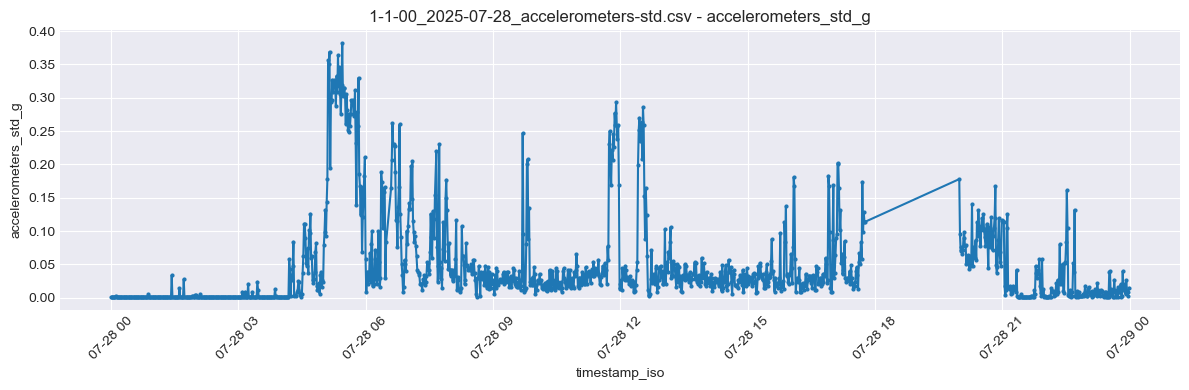

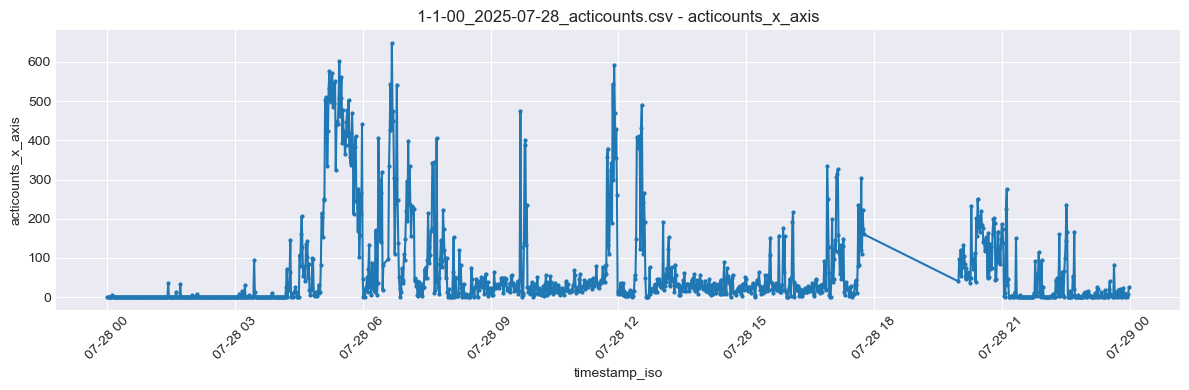

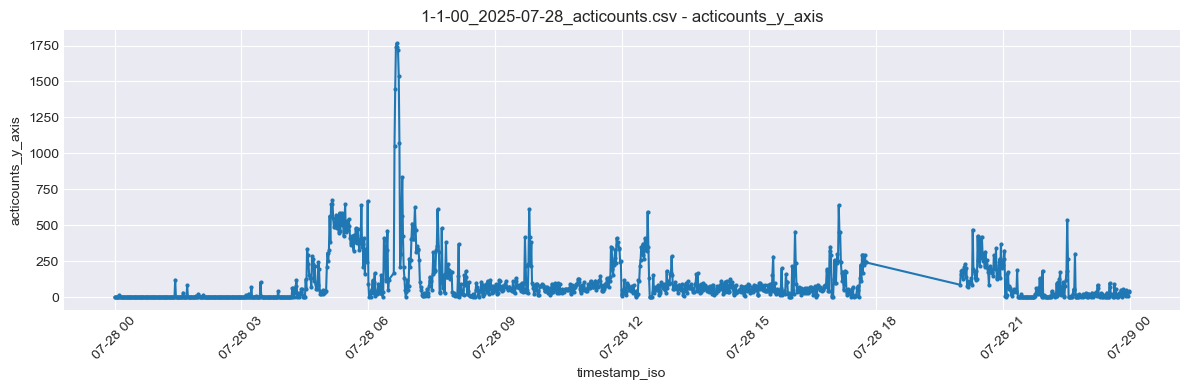

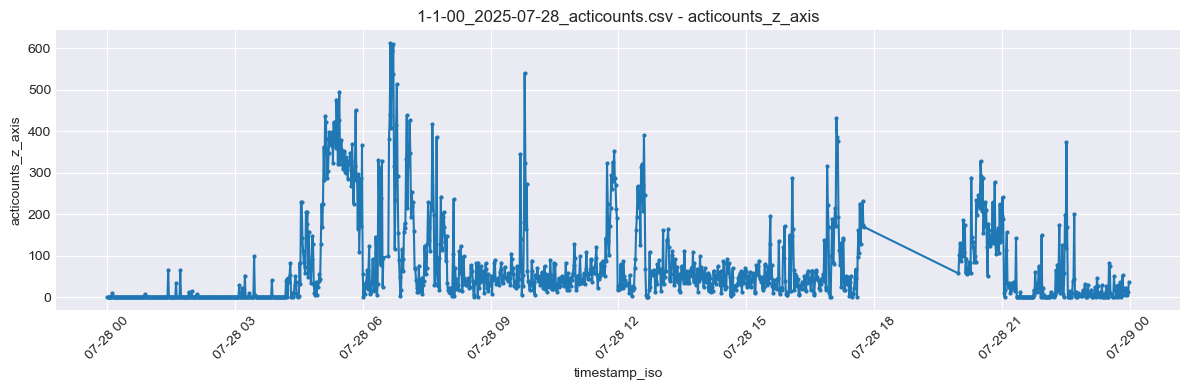

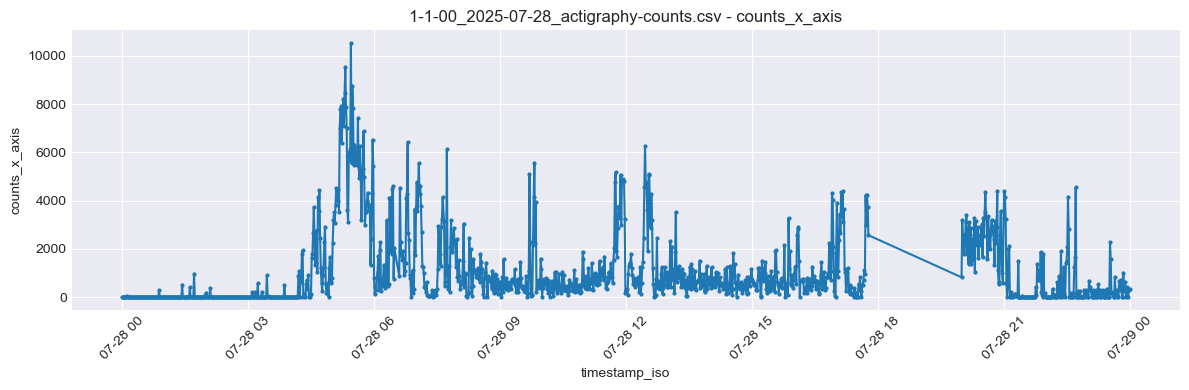

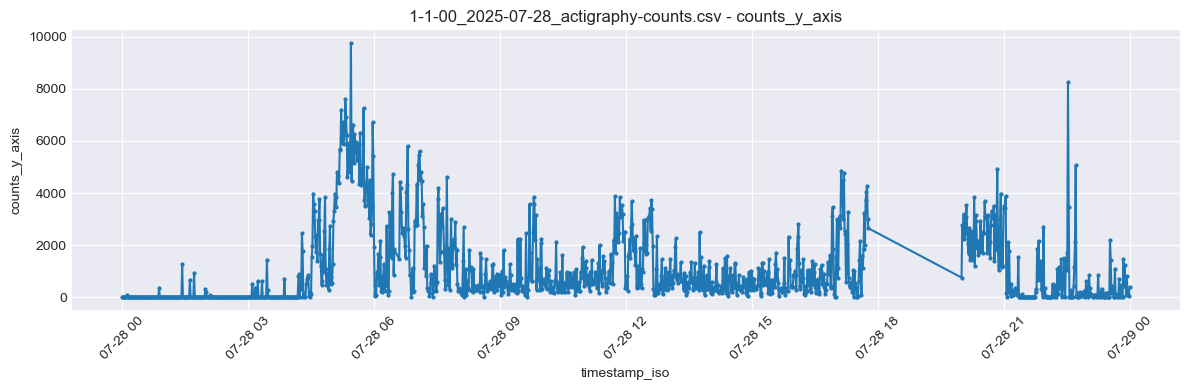

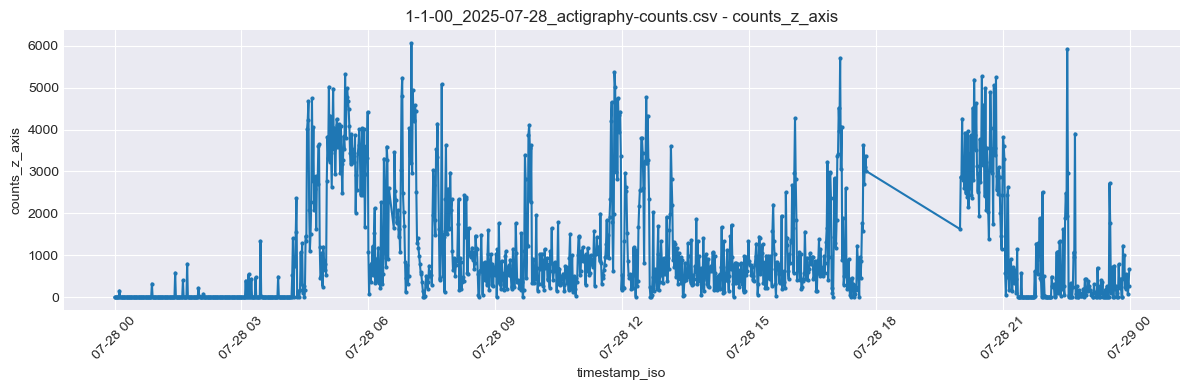

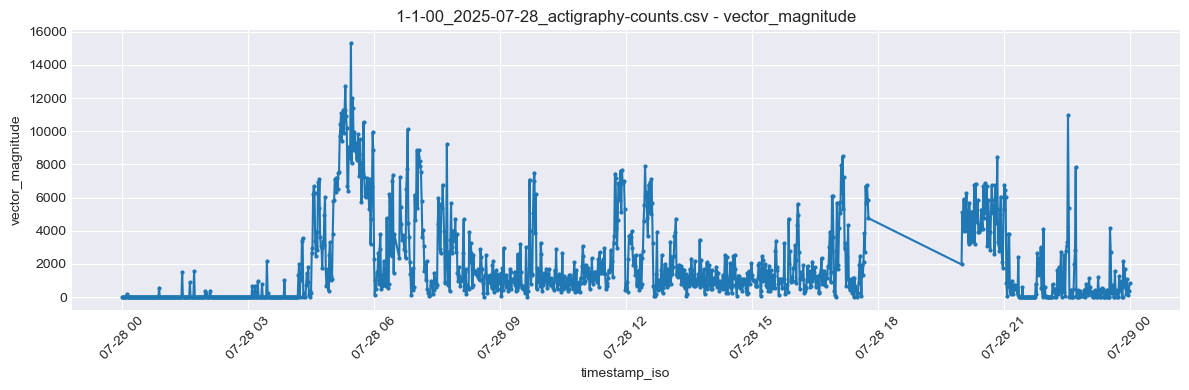

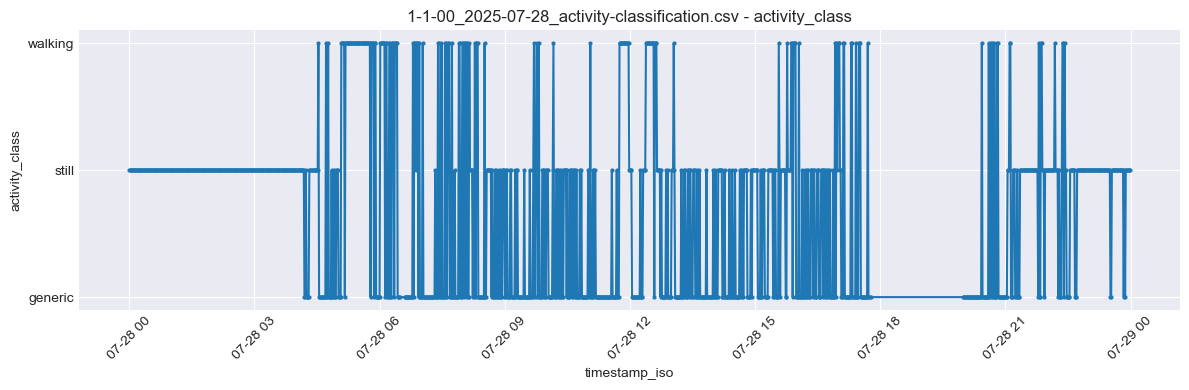

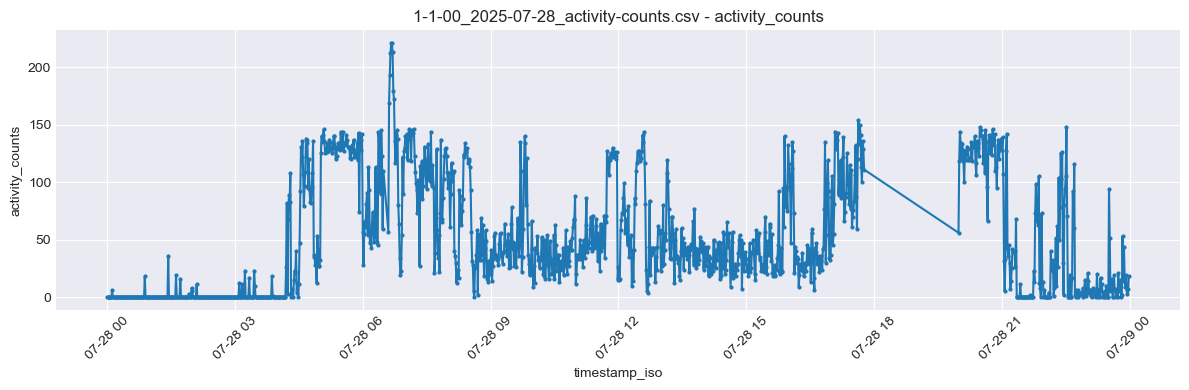

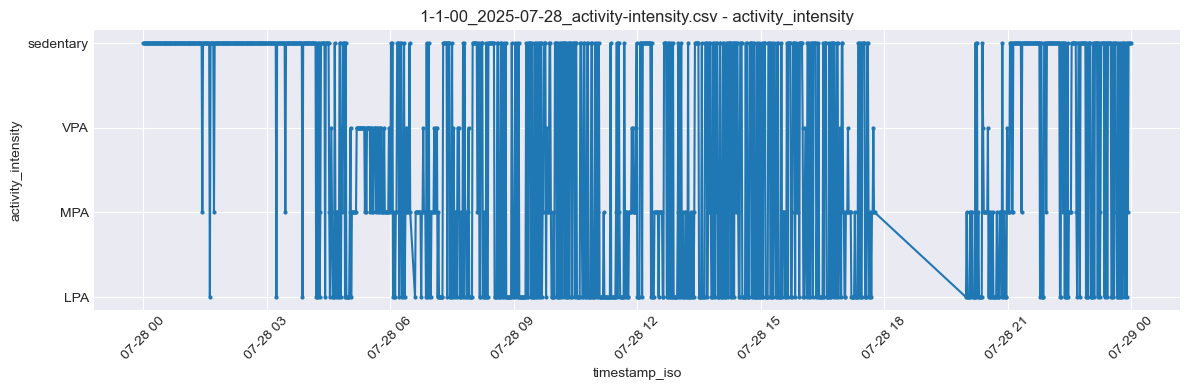

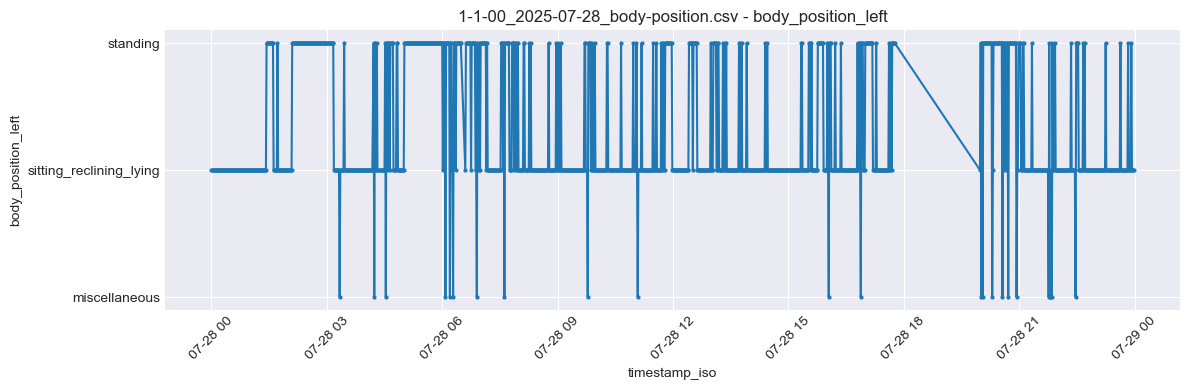

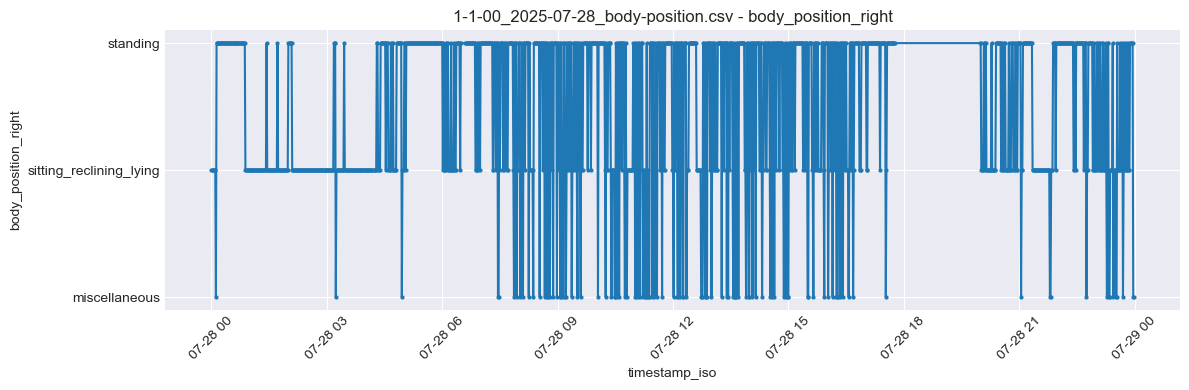

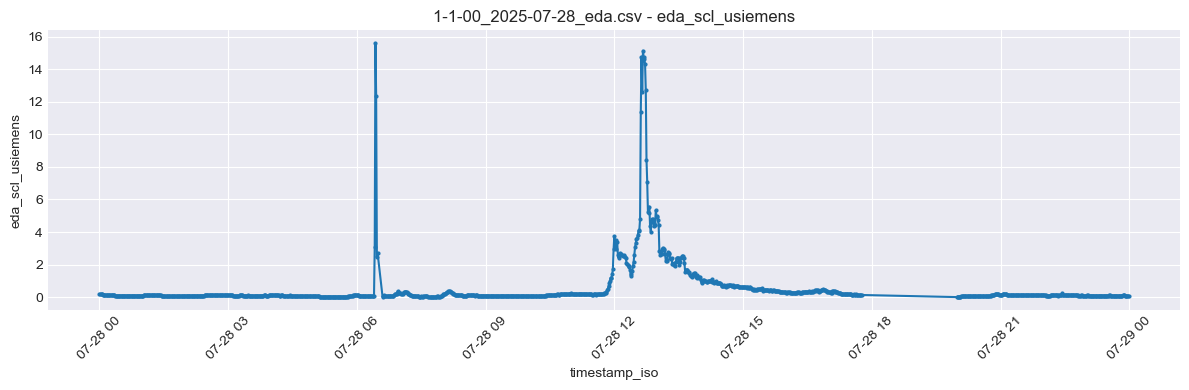

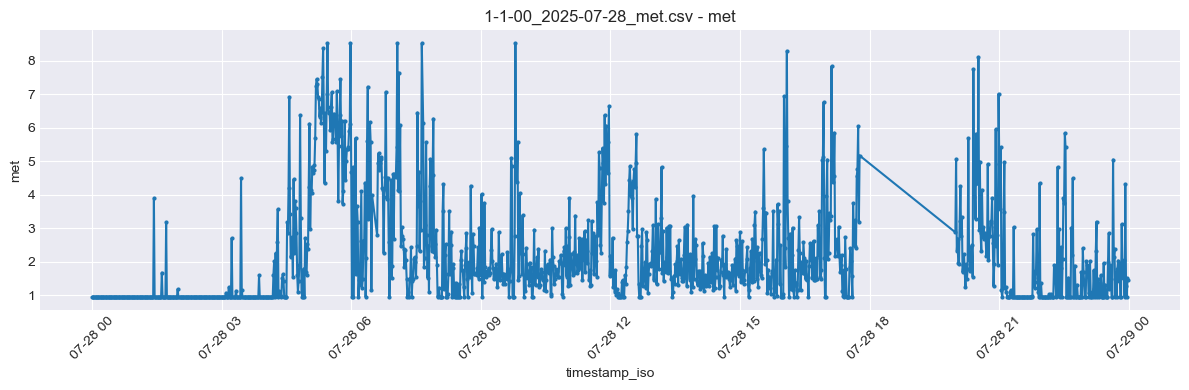

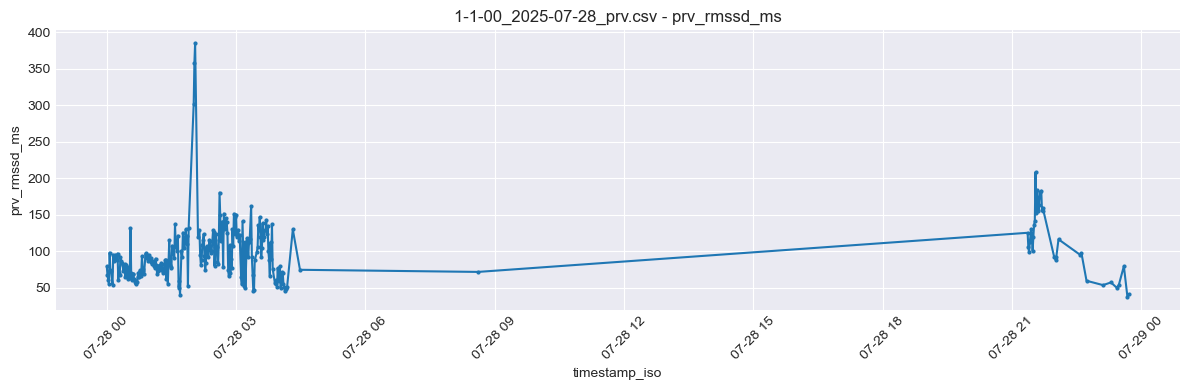

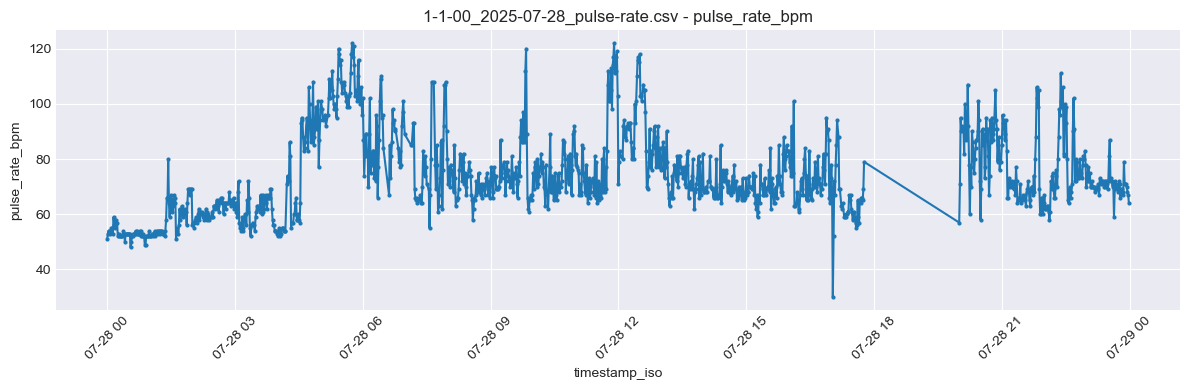

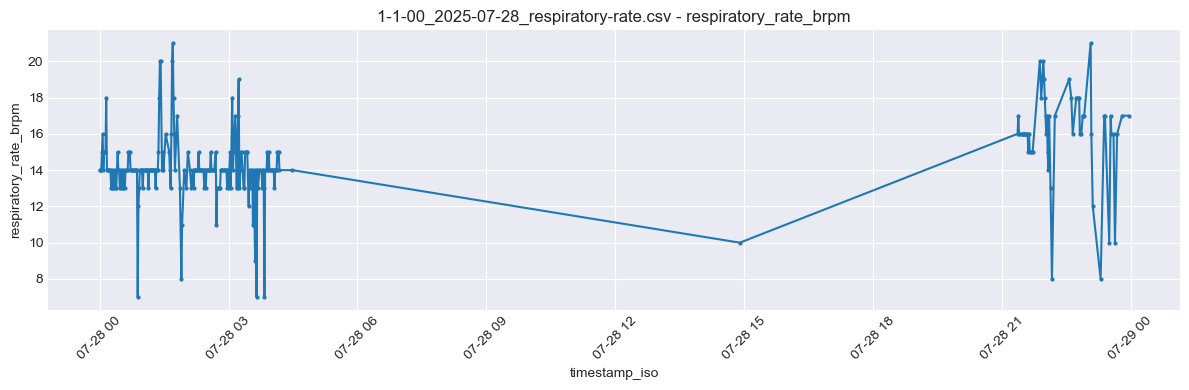

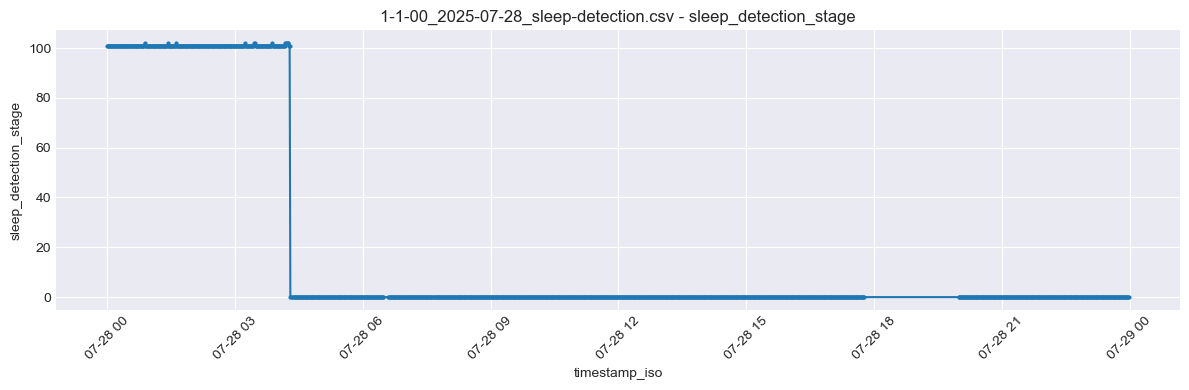

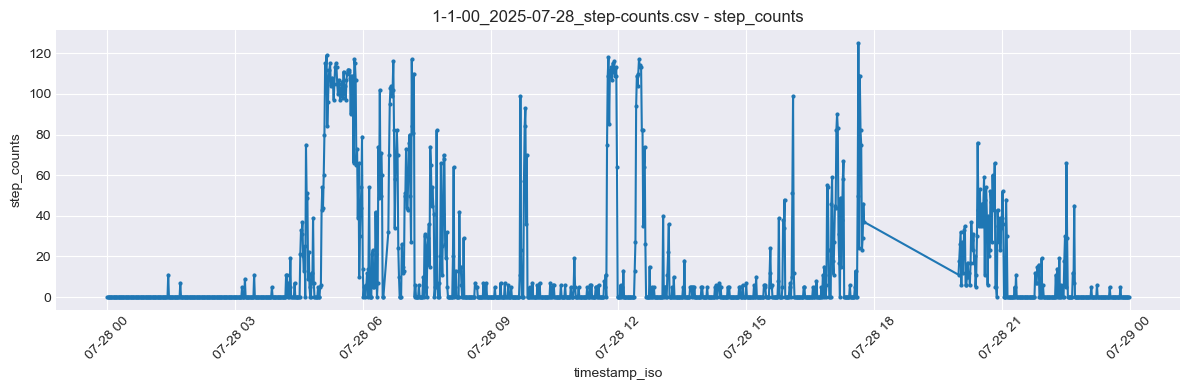

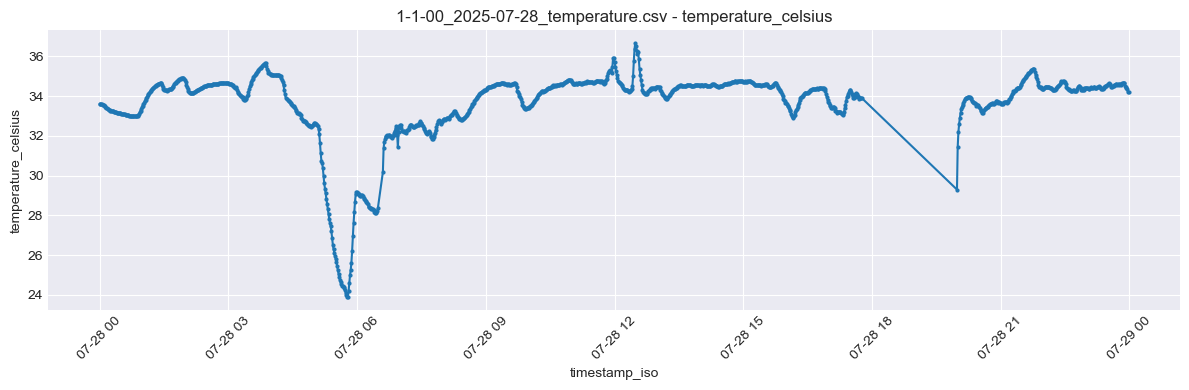

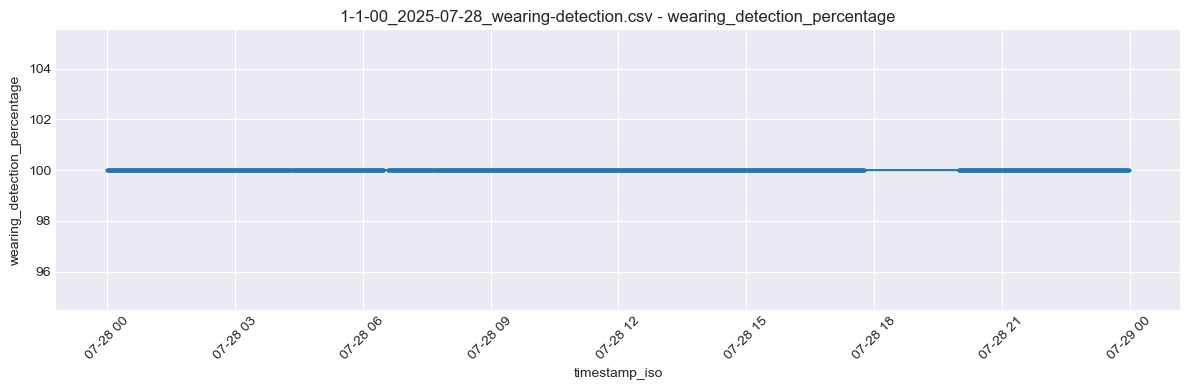

In [6]:
# Graficar timestamp_iso vs. las columnas entre participant_full_id y missing_value_reason
for nombre_archivo, dataframe in dataframes.items():
    columnas = list(dataframe.columns)

    if 'timestamp_iso' not in columnas or 'participant_full_id' not in columnas:
        print(f"Se omite {nombre_archivo}: faltan columnas requeridas.")
        continue

    inicio = columnas.index('participant_full_id') + 1
    fin = columnas.index('missing_value_reason') if 'missing_value_reason' in columnas else len(columnas)
    columnas_a_graficar = columnas[inicio:fin]

    if not columnas_a_graficar:
        print(f"Se omite {nombre_archivo}: no hay columnas para graficar.")
        continue

    x_plot = pd.to_datetime(dataframe['timestamp_iso'], errors='coerce')

    for columna_y in columnas_a_graficar:
        plt.figure(figsize=(12, 4))
        serie_y = dataframe[columna_y]

        # Intentar graficar como numérico; si no, como categórico
        serie_y_numerica = pd.to_numeric(serie_y, errors='coerce')

        if serie_y_numerica.notna().sum() > 0:
            mascara = x_plot.notna() & serie_y_numerica.notna()
            plt.plot(x_plot[mascara], serie_y_numerica[mascara], marker='o', linestyle='-', markersize=2)
        else:
            serie_y_categoria = serie_y.astype('category')
            mascara = x_plot.notna() & serie_y.notna()
            plt.plot(x_plot[mascara], serie_y_categoria.cat.codes[mascara], marker='o', linestyle='-', markersize=2)
            plt.yticks(
                range(len(serie_y_categoria.cat.categories)),
                serie_y_categoria.cat.categories
            )

        plt.title(f'{nombre_archivo} - {columna_y}')
        plt.xlabel('timestamp_iso')
        plt.ylabel(columna_y)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

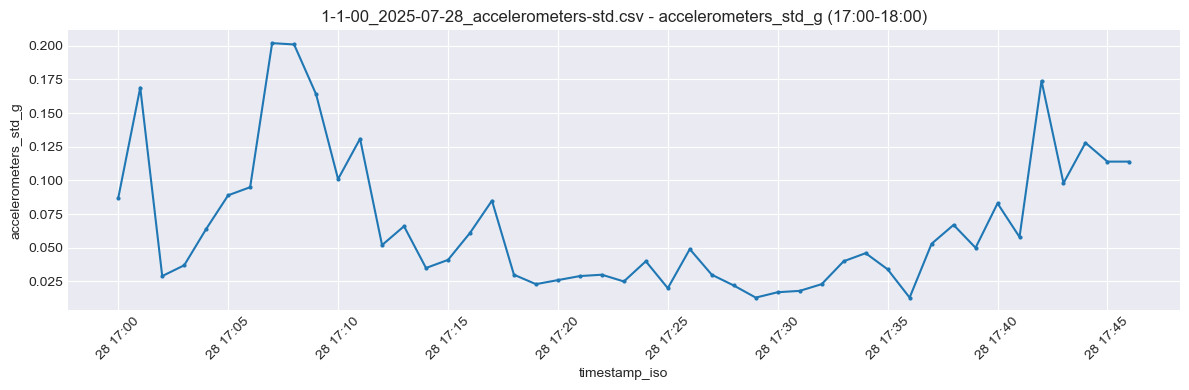

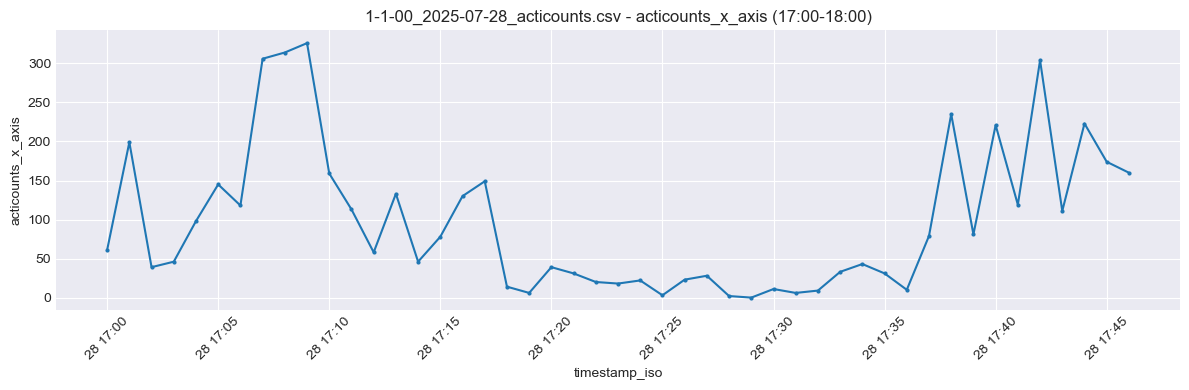

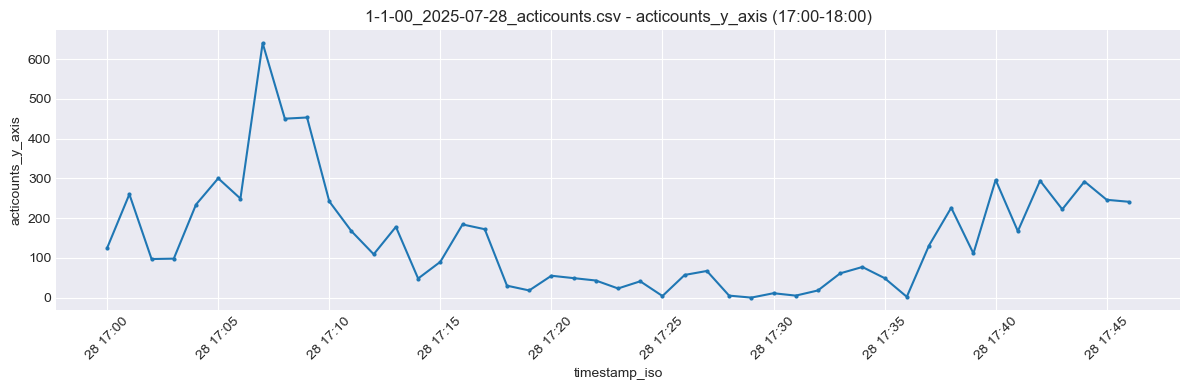

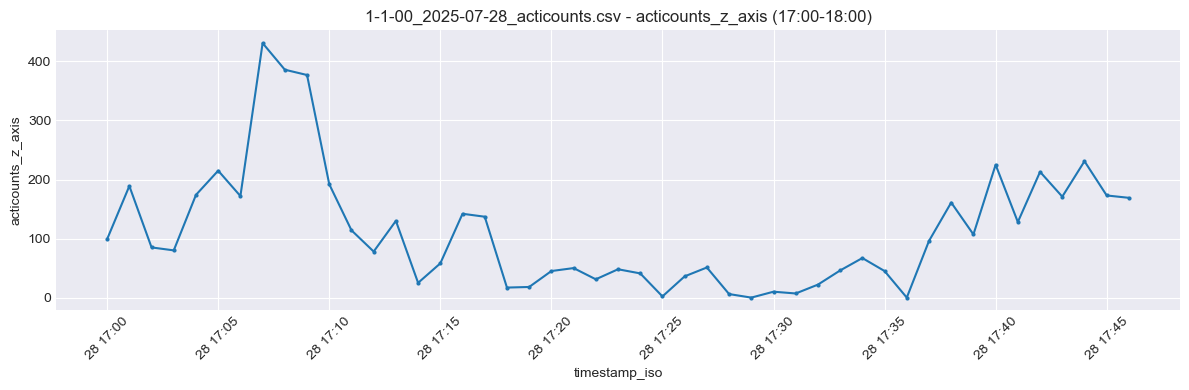

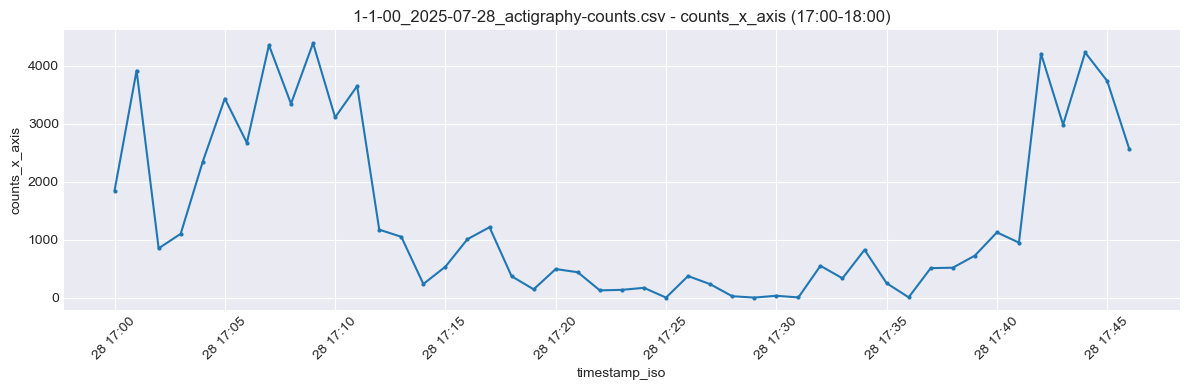

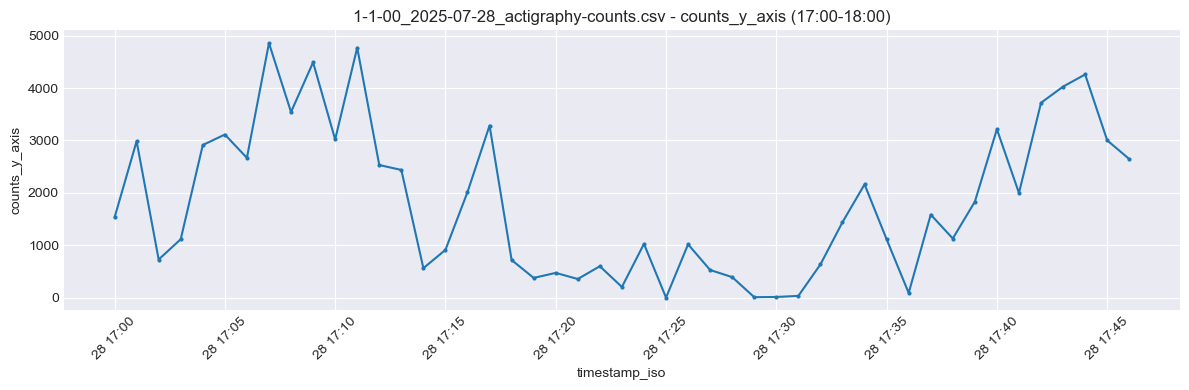

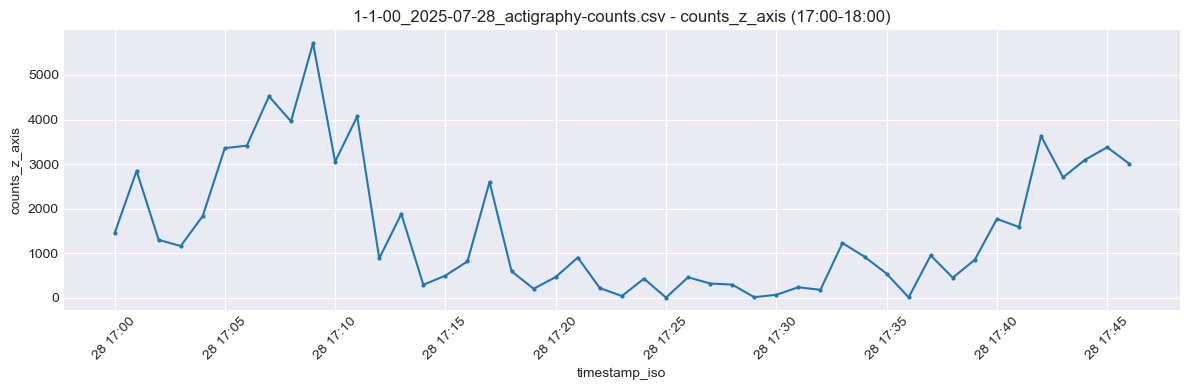

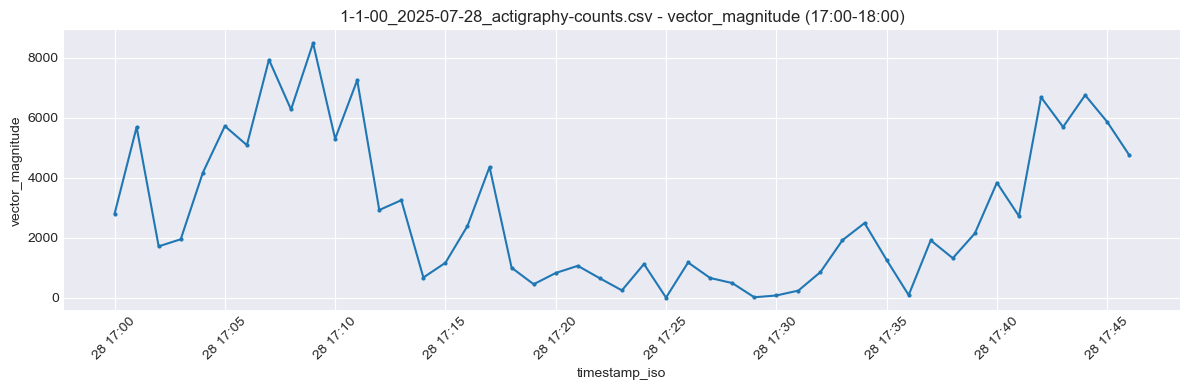

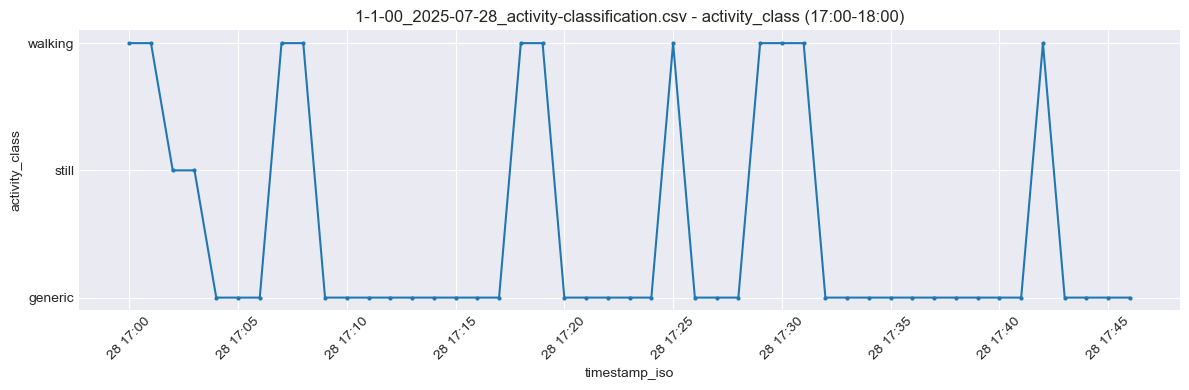

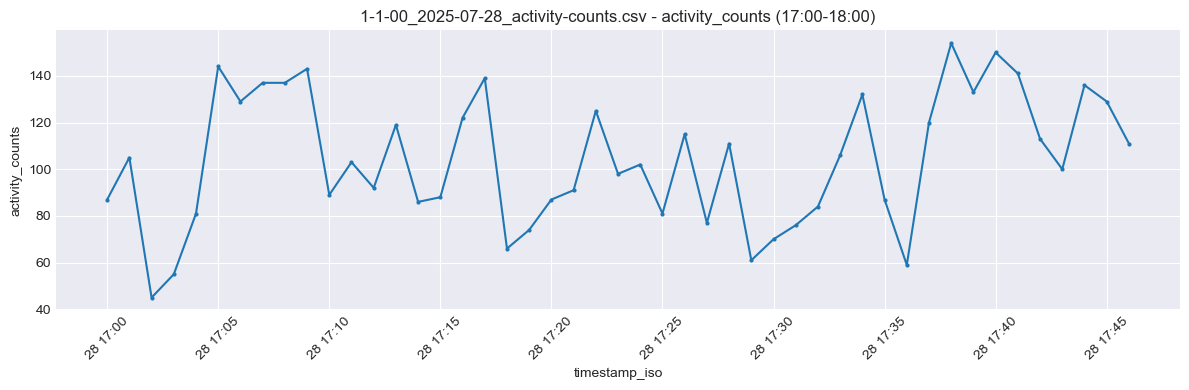

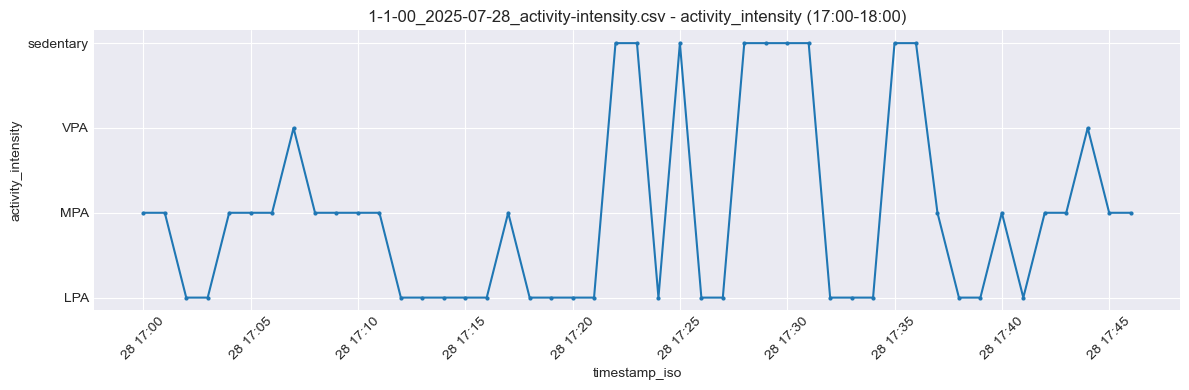

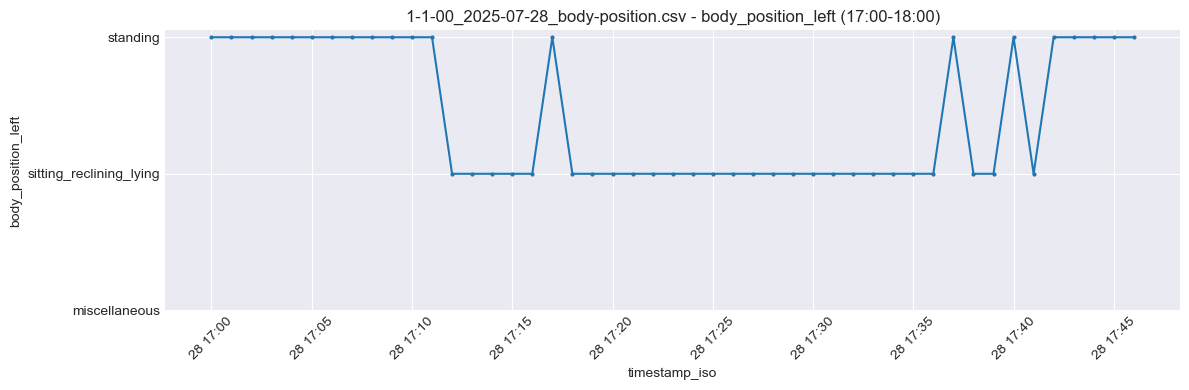

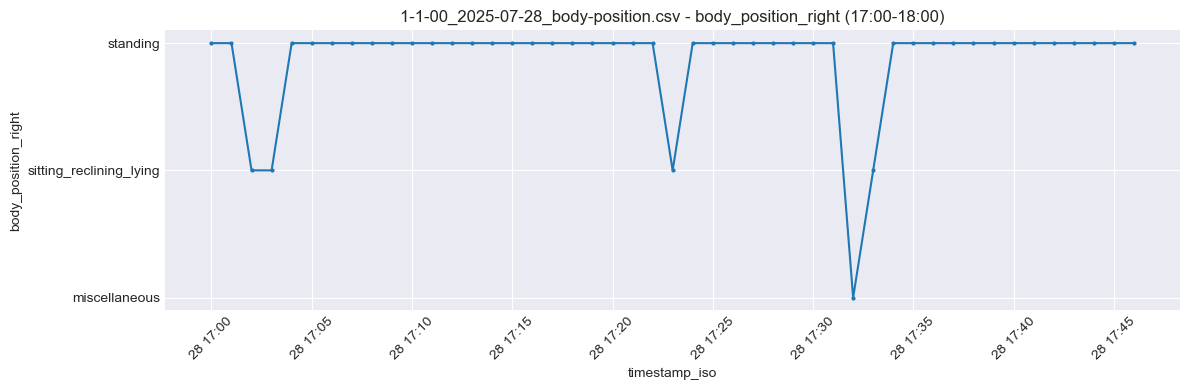

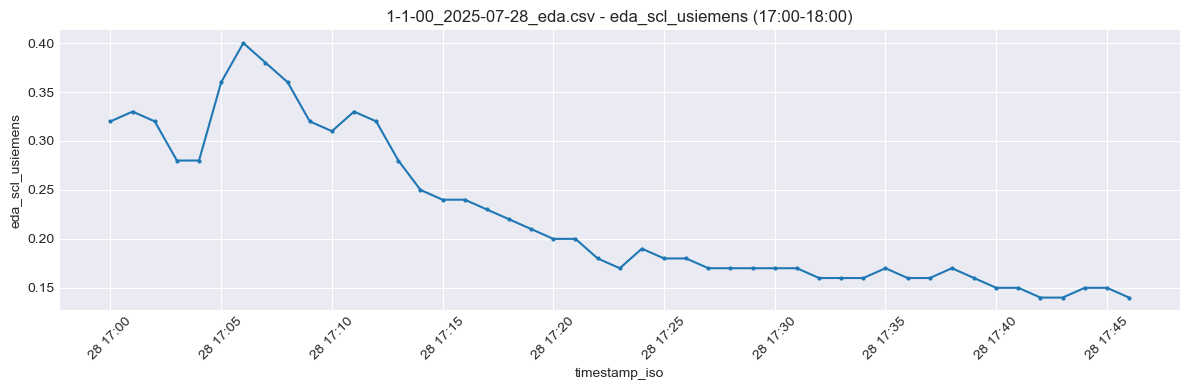

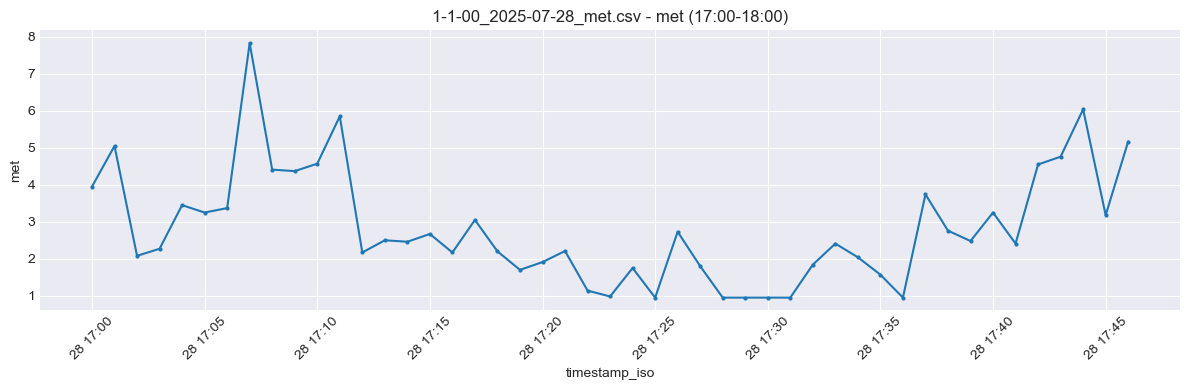

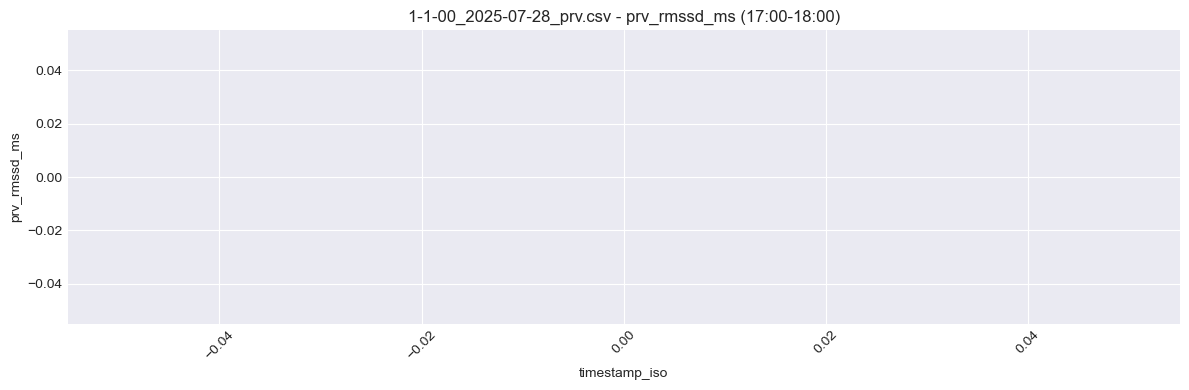

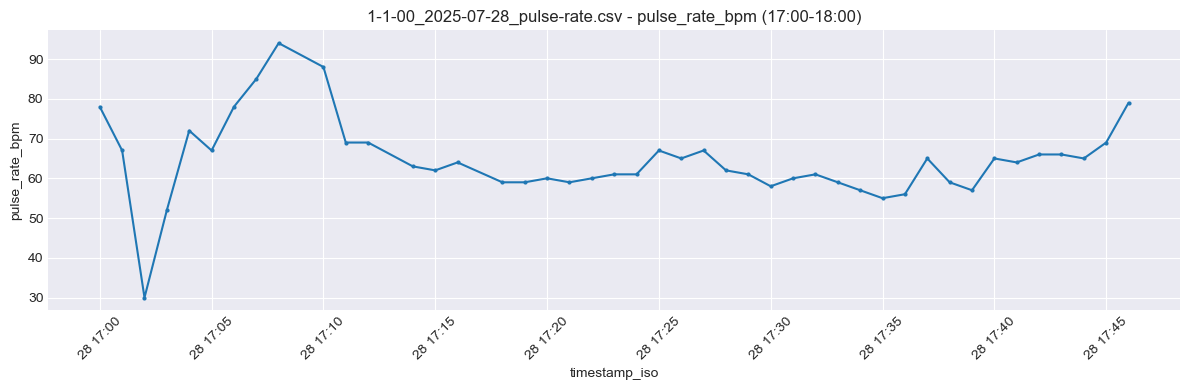

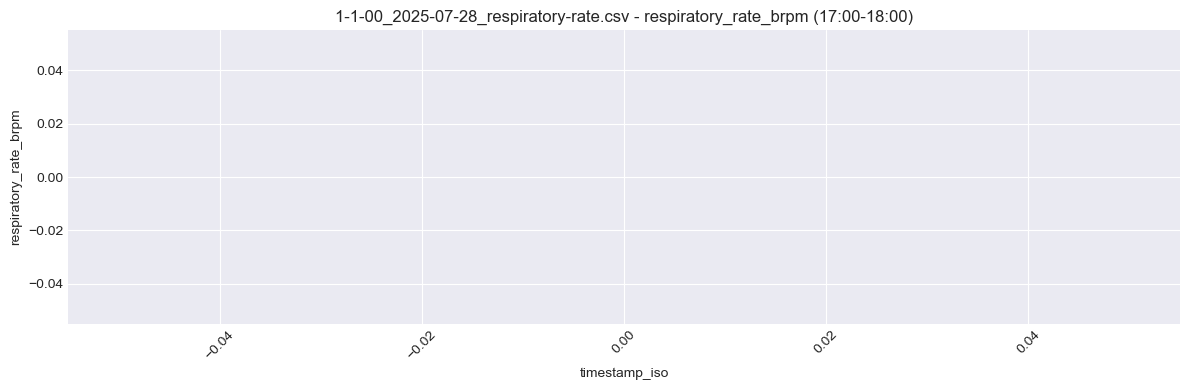

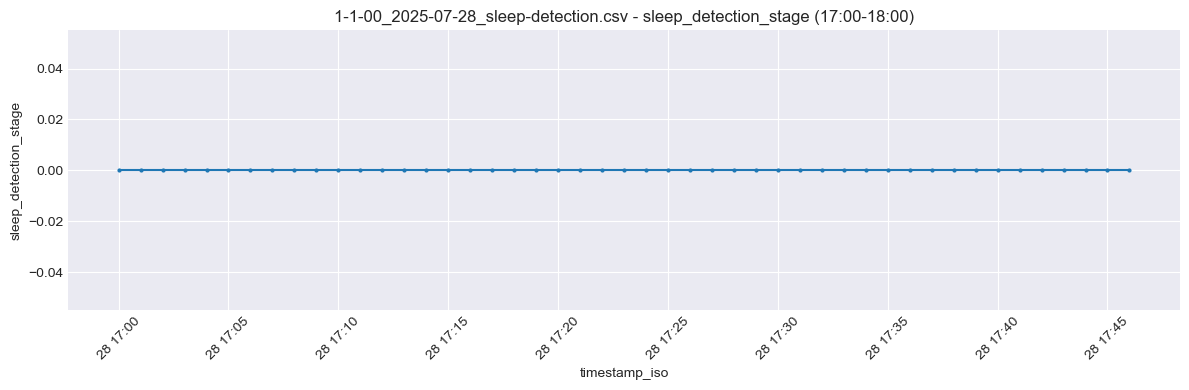

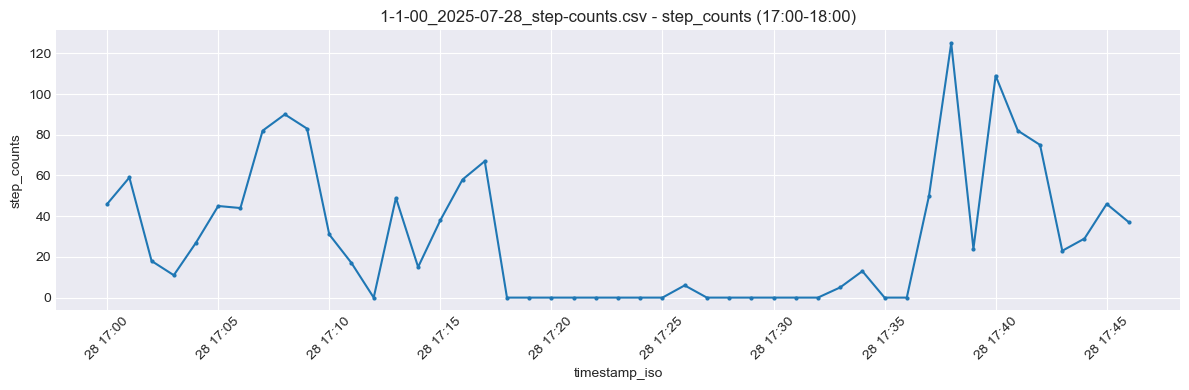

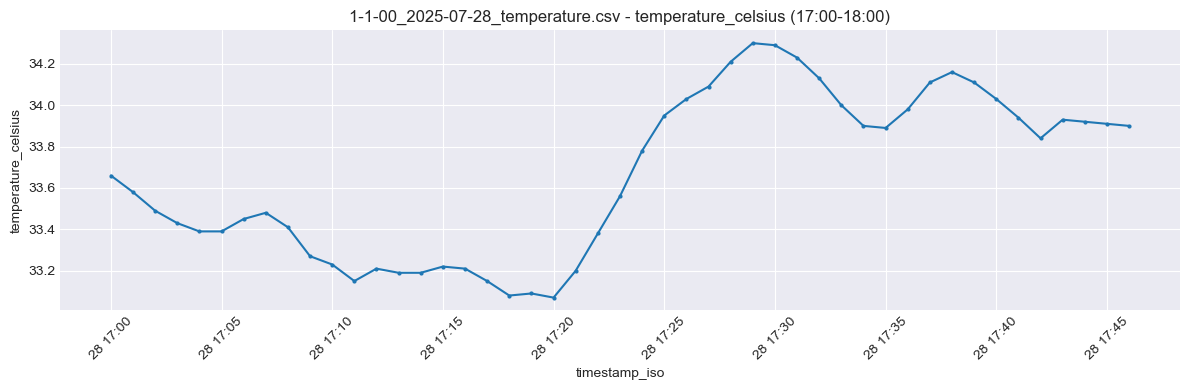

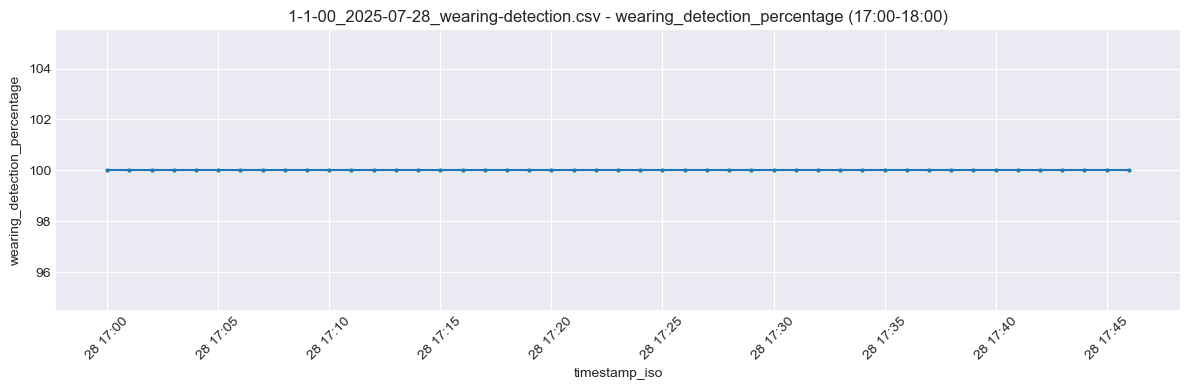

In [9]:
# Graficar timestamp_iso vs. columnas entre participant_full_id y missing_value_reason SOLO entre 17:00 y 18:00
for nombre_archivo, dataframe in dataframes.items():
    columnas = list(dataframe.columns)

    if 'timestamp_iso' not in columnas or 'participant_full_id' not in columnas:
        print(f"Se omite {nombre_archivo}: faltan columnas requeridas.")
        continue

    inicio = columnas.index('participant_full_id') + 1
    fin = columnas.index('missing_value_reason') if 'missing_value_reason' in columnas else len(columnas)
    columnas_a_graficar = columnas[inicio:fin]

    if not columnas_a_graficar:
        print(f"Se omite {nombre_archivo}: no hay columnas para graficar.")
        continue

    x_plot = pd.to_datetime(dataframe['timestamp_iso'], errors='coerce')
    # Filtrar SOLO entre 17:00 y 18:00
    mask_hora = (x_plot.dt.hour == 17)

    for columna_y in columnas_a_graficar:
        plt.figure(figsize=(12, 4))
        serie_y = dataframe[columna_y]

        # Intentar graficar como numérico; si no, como categórico
        serie_y_numerica = pd.to_numeric(serie_y, errors='coerce')

        if serie_y_numerica.notna().sum() > 0:
            mascara = x_plot.notna() & serie_y_numerica.notna() & mask_hora
            plt.plot(x_plot[mascara], serie_y_numerica[mascara], marker='o', linestyle='-', markersize=2)
        else:
            serie_y_categoria = serie_y.astype('category')
            mascara = x_plot.notna() & serie_y.notna() & mask_hora
            plt.plot(x_plot[mascara], serie_y_categoria.cat.codes[mascara], marker='o', linestyle='-', markersize=2)
            plt.yticks(
                range(len(serie_y_categoria.cat.categories)),
                serie_y_categoria.cat.categories
            )

        plt.title(f'{nombre_archivo} - {columna_y} (17:00-18:00)')
        plt.xlabel('timestamp_iso')
        plt.ylabel(columna_y)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
